# U.S. Presidential Election County-Level Analysis
### Group Project — AI & Python Course
**Student IDs:** [...]

## Introduction

The United States presidential election is decided not by  an Electoral College system in which each state awards its vote based on the state's majority vote. Because different counties within a state vary enormously in population size, a relatively small number of high-population counties often cast the majority of a state's total votes, making them disproportionately important in shaping the final result. Understanding which counties are most influential, and which political party tends to win them, can be meaningful in helping derive  how political geography drives election outcomes.

This project analyzes county-level presidential election results to answer four main questions: (1) Which counties are most influential in each state, measured by their share of total state votes? (2) Which political party wins those top counties? (3) Do top-county party preferences align with the overall state outcome? (4) How does county influence vary across different election results? This helps us answer our main question:
#### Does a specific party winning in a county increase its chances of winning in bigger elections (Senate, Governor, Presidential)?

Our analysis finds that __________


---
**Structure of this notebook:**
1. Data Description & Import
2. Data Merging & Cleaning
3. Results & Analysis
4. Discussion

## Section 1

### Data Description & Import

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

We use four datasets from the 2020 U.S. general election. 
The primary datasets are: `president_county_candidate.csv`, `senate_county_candidate.csv`, `governors_county_candidate.csv`, and `house_candidate.csv`

In [3]:
pres   = pd.read_csv('president_county_candidate.csv')
senate = pd.read_csv('senate_county_candidate.csv')
gov    = pd.read_csv('governors_county_candidate.csv')
house  = pd.read_csv('house_candidate.csv')

The "president_county_condidate.csv" shows how one row per candidate per county, covering 51 states/territories. Each row records the state, county name, candidate name, party affiliation, total votes received, and whether the candidate won that county. 

## Section 2

### Data Merging and Cleaning

In [4]:
senate_state = senate.groupby(['state', 'party'])['total_votes'].sum().reset_index()

pres_merged = pd.merge(pres, senate_state, on='state', how='left', suffixes=('', '_senate'))
pres_merged.head()

,state,county,candidate,party,total_votes,won,party_senate,total_votes_senate
0,Delaware,Kent County,Joe Biden,DEM,44552,True,DEM,56137.0
1,Delaware,Kent County,Joe Biden,DEM,44552,True,IPD,7833.0
2,Delaware,Kent County,Joe Biden,DEM,44552,True,LIB,5244.0
3,Delaware,Kent County,Joe Biden,DEM,44552,True,REP,118652.0
4,Delaware,Kent County,Donald Trump,REP,41009,False,DEM,56137.0


This merge tells us the total number of votes per party per state which tells us the prevailing parties across states. 
Next, we merge this dataset with the presidential candidate dataset on the `state` column. This allows for the president winners to also be compared to the parties and those that won at a senate level.

In [5]:
major_parties = ['DEM', 'REP']

def big_parties(party):
    if party in major_parties:
        return party
    else:
        return 'OTH'
    
pres_merged['party'] = pres_merged['party'].apply(big_parties)


This helps simplify the data to only look at the bigger dual party system which dominates election results to keep analysis simple. 

In [6]:
state_totals = pres_merged.groupby('state')['total_votes'].sum().reset_index()

county_totals = pres_merged.groupby(['state', 'county'])['total_votes'].sum().reset_index()

merged = pd.merge(county_totals, state_totals, on='state', suffixes=('_county', '_state'))

merged['vote_share'] = (merged['total_votes_county'] / merged['total_votes_state']).round(2)

top = merged.sort_values('vote_share', ascending=False)
top10 = top.head(10)
top10

,state,county,total_votes_county,total_votes_state,vote_share
2747,Nevada,Clark County,972510,1405376,0.69
726,Hawaii,Honolulu County,382114,574469,0.67
114,Arizona,Maricopa County,6208425,10161978,0.61
489,Delaware,New Castle County,1150532,2016040,0.57
4053,Utah,Salt Lake County,541175,1488289,0.36
3020,New Mexico,Bernalillo County,952770,2771895,0.34
788,Illinois,Cook County,13928394,43293006,0.32
729,Idaho,Ada County,1037556,3472424,0.30
4460,Washington,King County,1210507,4087631,0.30
2679,Nebraska,Douglas County,829620,2869137,0.29


This is an important table. First, it finds the total number of votes in each state, following which is finds the total in each county. Next, it merges the two datasets to show a table with the total votes in each county in each state. Then, a new column is added known as "vote_share" which essentially shows the ratio of total shares in a state made up by a particular county, following which, sorting them in ascending order and displaying the first 5, allow for the top 5 most influential counties in each state to be identified. 

## Section 3

### Results and Analysis

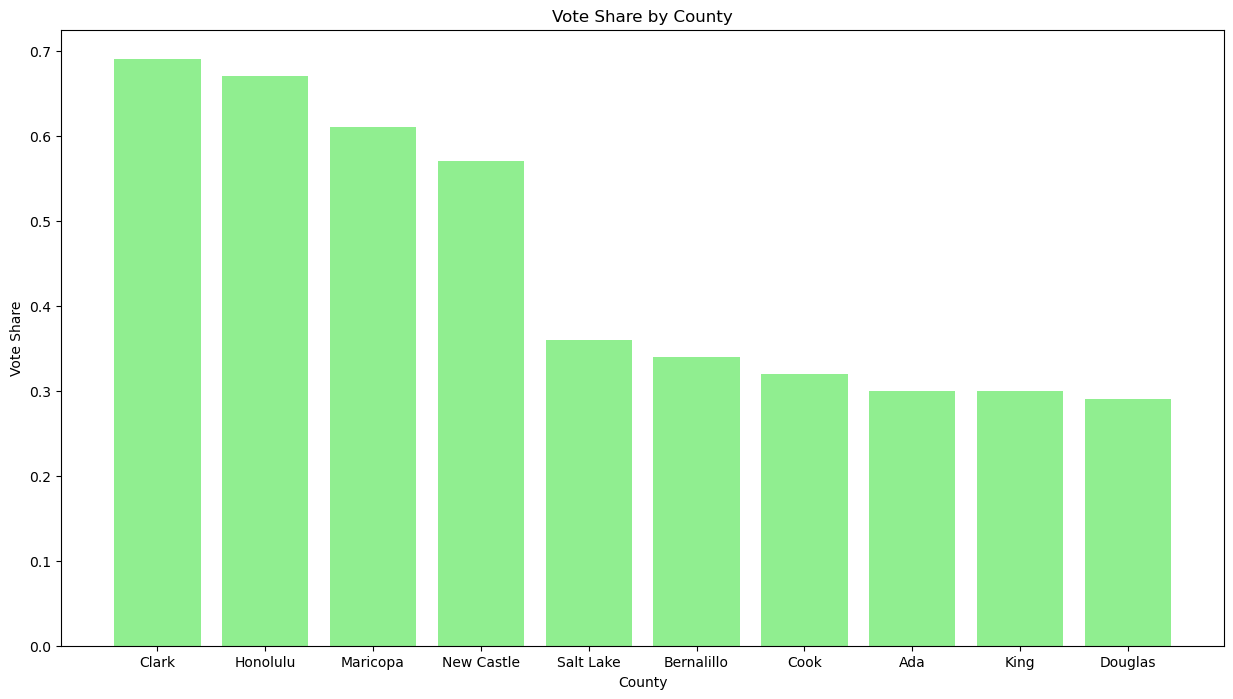

In [7]:
y = np.array(top10["county"])
z = []

for x in y:
    if "County" in x:
        a = len(x)
        b = a - 7
        new = x[:b]
        z.append(new)

plt.figure(figsize=(15, 8))        
plt.bar(x = z, height = top10["vote_share"], color = "lightgreen")
plt.title("Vote Share by County")
plt.xlabel("County")
plt.ylabel("Vote Share")
plt.show()


A visualisation of the votershare across counties. 

In [37]:
winners = pres_merged[pres_merged["won"] == True]

top_winners = pd.merge(winners, top10[["state", "county"]], on = ["state", "county"])

new_party = []
for x in (top_winners["party"]):
    if x == "DEM":
        y = 1
        new_party.append(y)
    else:
        f = 0
        new_party.append(f)
    
top_winners["count"] = new_party

percent_dem = (top_winners["count"].sum() / top_winners.shape[0])*100
print((percent_dem).round(2))

85.19


The democrats won the 2020 presidential election which tells us that more than 80% of the counties considered influential voted democratic. Now to check if this is consistent with the outcome for state elections by looking at the values for how these states affected the governor elections:


In [58]:
winners_gov = gov[gov["won"] == True]

state_party_votes = winners_gov.groupby(['state', 'party'])['votes'].sum()
state_party_votes.reset_index().head()

,state,party,votes
0,Delaware,DEM,236030
1,Delaware,REP,68435
2,Indiana,DEM,348860
3,Indiana,REP,1434873
4,Missouri,DEM,666952


In [66]:
dem = winners_gov[winners_gov['party'] == 'DEM']

check_winner = (dem["votes"].sum() / winners_gov["votes"].sum())*100
print(check_winner.round(2))


40.4


This shows that while, the democrats won the presidential election, they did not win a lot of the state elections during the governor's elections. However, 

In [62]:
top_winners_gov = pd.merge(winners_gov, top10[["state", "county"]], on = ["state", "county"])

new_party = []
for x in (top_winners_gov["party"]):
    if x == "DEM":
        y = 1
        new_party.append(y)
    else:
        f = 0
        new_party.append(f)
    
top_winners_gov["count"] = new_party

percent_dem_gov = (top_winners_gov["count"].sum() / top_winners_gov.shape[0])*100
print((percent_dem_gov).round(2))

66.67


This shows that of all the counties that were previously determined to be most influential, and the ones that were involved in the governor's elections, they still made up 2/3rds of the overall democratic vote. This is a more accurate determinant of how influential these counties can be since, even though only 1/3rd of them were included in the governor elections. 

## Section 4

### Discussion

This analysis shows that a small number of high-population counties contribute disproportionately to total state vote counts, making them highly influential in determining election outcomes. These counties may not necesarily determine the state outcomes and overall governor outcomes since, they may not be all be involved however, they tend to make up a majority vote for the party that they go for. The presedential election was a Democratic win and 85% of the counties voted Democratic. For governors, only 40% of the overall votes were democratic but, 66% of the influential counties included voted democratic whereas only, a third were in the governor elections this time. This shows how certain areas may disproportionately affect election results: it may not always be enough to predict them but, they do have a higher impact than others,